In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/flowers-recognition


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torch.utils.data import random_split

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to 128x128
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load dataset
data_dir = path +'/flowers'
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(dataset.classes)

dataset_size = len(dataset)  # Assuming 'dataset' is your ImageFolder dataset
train_size = int(0.8 * dataset_size)  # 80% for training
val_size = int(0.1 * dataset_size)  # 10% for validation
test_size = dataset_size - train_size - val_size  # Remaining 10% for testing


train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)

valloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

testloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


torch.Size([64, 3, 224, 224])
torch.Size([64])


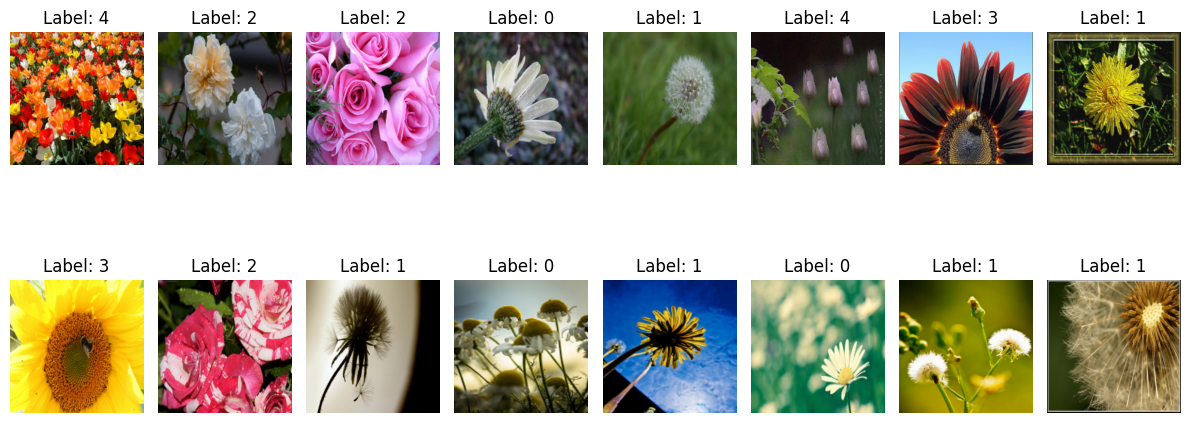

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of data from the dataloader
images, labels = next(iter(trainloader))
print(images.shape)
print(labels.shape)

# Display a grid of images
fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(12, 6))  # Adjust grid size as needed
for i, ax in enumerate(axes.flat):
    # Convert the image from a PyTorch tensor to a NumPy array
    image = images[i].numpy().transpose(1, 2, 0)
    # Un-normalize the image
    image = image * np.array([0.5, 0.5, 0.5]) + np.array([0.5, 0.5, 0.5])
    # Clip the pixel values to the range [0, 1]
    image = np.clip(image, 0, 1)
    # Display the image
    ax.imshow(image)
    ax.set_title(f"Label: {labels[i].item()}")  # Assuming labels are integers
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
class vgg16(nn.Module):
  def __init__(self, num_classes=10):
    super(vgg16, self).__init__()

    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(64)
    self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)
    self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(128)

    self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn5 = nn.BatchNorm2d(256)
    self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn6 = nn.BatchNorm2d(256)
    self.conv7 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn7 = nn.BatchNorm2d(256)

    self.conv8 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
    self.bn8 = nn.BatchNorm2d(512)
    self.conv9 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn9 = nn.BatchNorm2d(512)
    self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn10 = nn.BatchNorm2d(512)

    self.conv11 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn11 = nn.BatchNorm2d(512)
    self.conv12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn12 = nn.BatchNorm2d(512)
    self.conv13 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn13 = nn.BatchNorm2d(512)

    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    self.fc1 = nn.Linear(512 * 7 * 7, 4096)
    self.dropuot = nn.Dropout(0.5)
    self.fc2 = nn.Linear(4096, 4096)
    self.fc3 = nn.Linear(4096, num_classes)

  def forward(self, x):
    feature_map1 = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(feature_map1)))
    x = self.pool(x)

    feature_map2 = F.relu(self.bn3(self.conv3(x)))
    x = F.relu(self.bn4(self.conv4(feature_map2)))
    x = self.pool(x)

    feature_map3 = F.relu(self.bn5(self.conv5(x)))
    x = F.relu(self.bn6(self.conv6(feature_map3)))
    x = F.relu(self.bn7(self.conv7(x)))
    x = self.pool(x)

    feature_map4 = F.relu(self.bn8(self.conv8(x)))
    x = F.relu(self.bn9(self.conv9(feature_map4)))
    x = F.relu(self.bn10(self.conv10(x)))
    x = self.pool(x)

    feature_map5 = F.relu(self.bn11(self.conv11(x)))
    x = F.relu(self.bn12(self.conv12(feature_map5)))
    x = F.relu(self.bn13(self.conv13(x)))
    x = self.pool(x)

    x = x.view(-1, 512 * 7 * 7)
    x = F.relu(self.fc1(x))
    x = self.dropuot(x)
    x = F.relu(self.fc2(x))
    x = self.dropuot(x)
    x = self.fc3(x)
    return x, feature_map1, feature_map2, feature_map3, feature_map4, feature_map5

input = torch.randn(1, 3, 224, 224)
model = vgg16()
output = model(input)
for i in range(6):
  print(output[i].shape)


torch.Size([1, 10])
torch.Size([1, 64, 224, 224])
torch.Size([1, 128, 112, 112])
torch.Size([1, 256, 56, 56])
torch.Size([1, 512, 28, 28])
torch.Size([1, 512, 14, 14])


In [ ]:
from tqdm import tqdm

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cpu'):

    # Lists to store loss and accuracy values
    training_losses = []
    trainig_accuracy = []
    validation_losses = []
    validation_accuracy = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in tqdm(train_loader, desc=f'Training Epoch [{epoch + 1}/{num_epochs}]'):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()  # Reset gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs[0], labels)  # Calculate loss
            _, predicted = torch.max(outputs[0].data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights
            running_loss += loss.item()

        training_losses.append(running_loss / len(train_loader))  # Average loss for the epoch
        trainig_accuracy.append(100 * correct / total)

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():  # Disable gradient calculation for validation
            for images, labels in tqdm(val_loader, desc='Validating'):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs[0], labels)
                val_loss += loss.item()

                # Calculate accuracy
                _, predicted = torch.max(outputs[0].data, 1)  # Get predicted class labels
                total += labels.size(0)  # Total number of samples
                correct += (predicted == labels).sum().item()  # Number of correct predictions

        validation_losses.append(val_loss / len(val_loader))  # Average validation loss
        validation_accuracy.append(100 * correct / total)  # Validation accuracy

        print(f"\nEpoch [{epoch + 1}/{num_epochs}], Training Loss: {training_losses[-1]:.4f}, Training Accuracy: {trainig_accuracy[-1]:.2f}% "
              f"Validation Loss: {validation_losses[-1]:.4f}, Validation Accuracy: {validation_accuracy[-1]:.2f}%")

    return training_losses, trainig_accuracy, validation_losses, validation_accuracy

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = vgg16(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
training_losses, trainig_accuracy, validation_losses, validation_accuracy = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=20, device = device)

Validating: 100%|██████████| 7/7 [00:00<00:00, 12.32it/s]



Epoch [1/20], Training Loss: 1.5681, Training Accuracy: 37.27% Validation Loss: 1.2503, Validation Accuracy: 46.17%


Validating: 100%|██████████| 7/7 [00:00<00:00, 12.32it/s]



Epoch [2/20], Training Loss: 1.1532, Training Accuracy: 55.14% Validation Loss: 1.4647, Validation Accuracy: 47.33%


Validating: 100%|██████████| 7/7 [00:00<00:00, 12.15it/s]


...


Epoch [18/20], Training Loss: 0.4253, Training Accuracy: 84.80% Validation Loss: 0.9281, Validation Accuracy: 68.91%


Validating: 100%|██████████| 7/7 [00:00<00:00, 12.02it/s]



Epoch [19/20], Training Loss: 0.3545, Training Accuracy: 87.37% Validation Loss: 0.8377, Validation Accuracy: 76.33%


Validating: 100%|██████████| 7/7 [00:00<00:00, 12.27it/s]


Epoch [20/20], Training Loss: 0.3392, Training Accuracy: 87.92% Validation Loss: 0.6825, Validation Accuracy: 75.87%


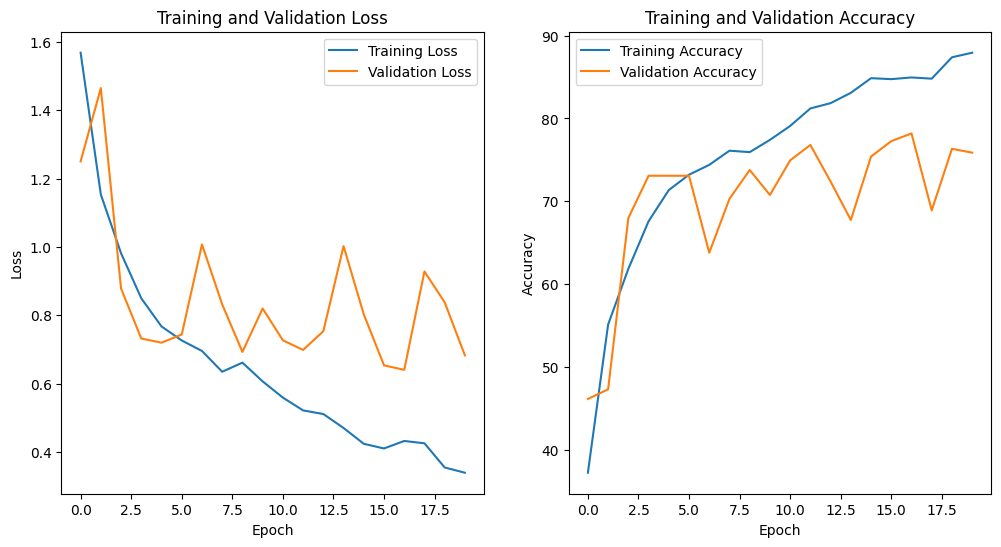

In [ ]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(training_losses, trainig_accuracy, validation_losses, validation_accuracy):

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Plot training and validation losses
    ax1.plot(training_losses, label='Training Loss')
    ax1.plot(validation_losses, label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Plot training and validation accuracies
    ax2.plot(trainig_accuracy, label='Training Accuracy')
    ax2.plot(validation_accuracy, label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.show()

plot_loss_accuracy(training_losses, trainig_accuracy, validation_losses, validation_accuracy)

In [ ]:
def test_model(model, test_loader, device='cpu'):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs[0].data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test images: {accuracy:.2f}%')

In [ ]:
test_model(model, testloader, device)

Accuracy of the model on the test images: 75.52%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_maps(model, image, layer_index):
  model.eval()
  image = image.unsqueeze(0).to(device)
  # Get the feature maps from the specified layer
  outputs = model(image)  # Add batch dimension
  feature_maps = outputs[layer_index + 1]

  image = image.squeeze(0).cpu().numpy().transpose(1, 2, 0)
  image = image * np.array([0.5, 0.5, 0.5]) + np.array([0.5, 0.5, 0.5])
  image = np.clip(image, 0, 1)
  plt.figure(figsize=(2, 2))
  plt.imshow(image)
  plt.title('Original Image')
  plt.axis('off')
  plt.show()
  # Plot the feature maps
  num_maps = feature_maps.shape[1]
  num_cols = 8 # Number of columns in the grid
  num_rows = int(np.ceil(num_maps / num_cols))  # Number of rows in the grid

  fig, axes = plt.subplots(num_rows, num_cols, figsize=(20,20))
  fig.subplots_adjust(hspace=0.5)

  for i, ax in enumerate(axes.flat):
    if i < num_maps:
      img = feature_maps[0, i].detach().cpu().numpy()  # Detach from graph, move to CPU, convert to NumPy
      ax.imshow(img, cmap='gray')
      ax.set_title(f'Feature Map {i + 1}')
      ax.axis('off')  # Hide axes ticks and labels
    else:
      ax.axis('off')  # Hide extra axes

  plt.show()

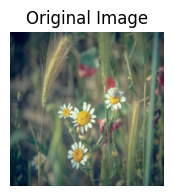

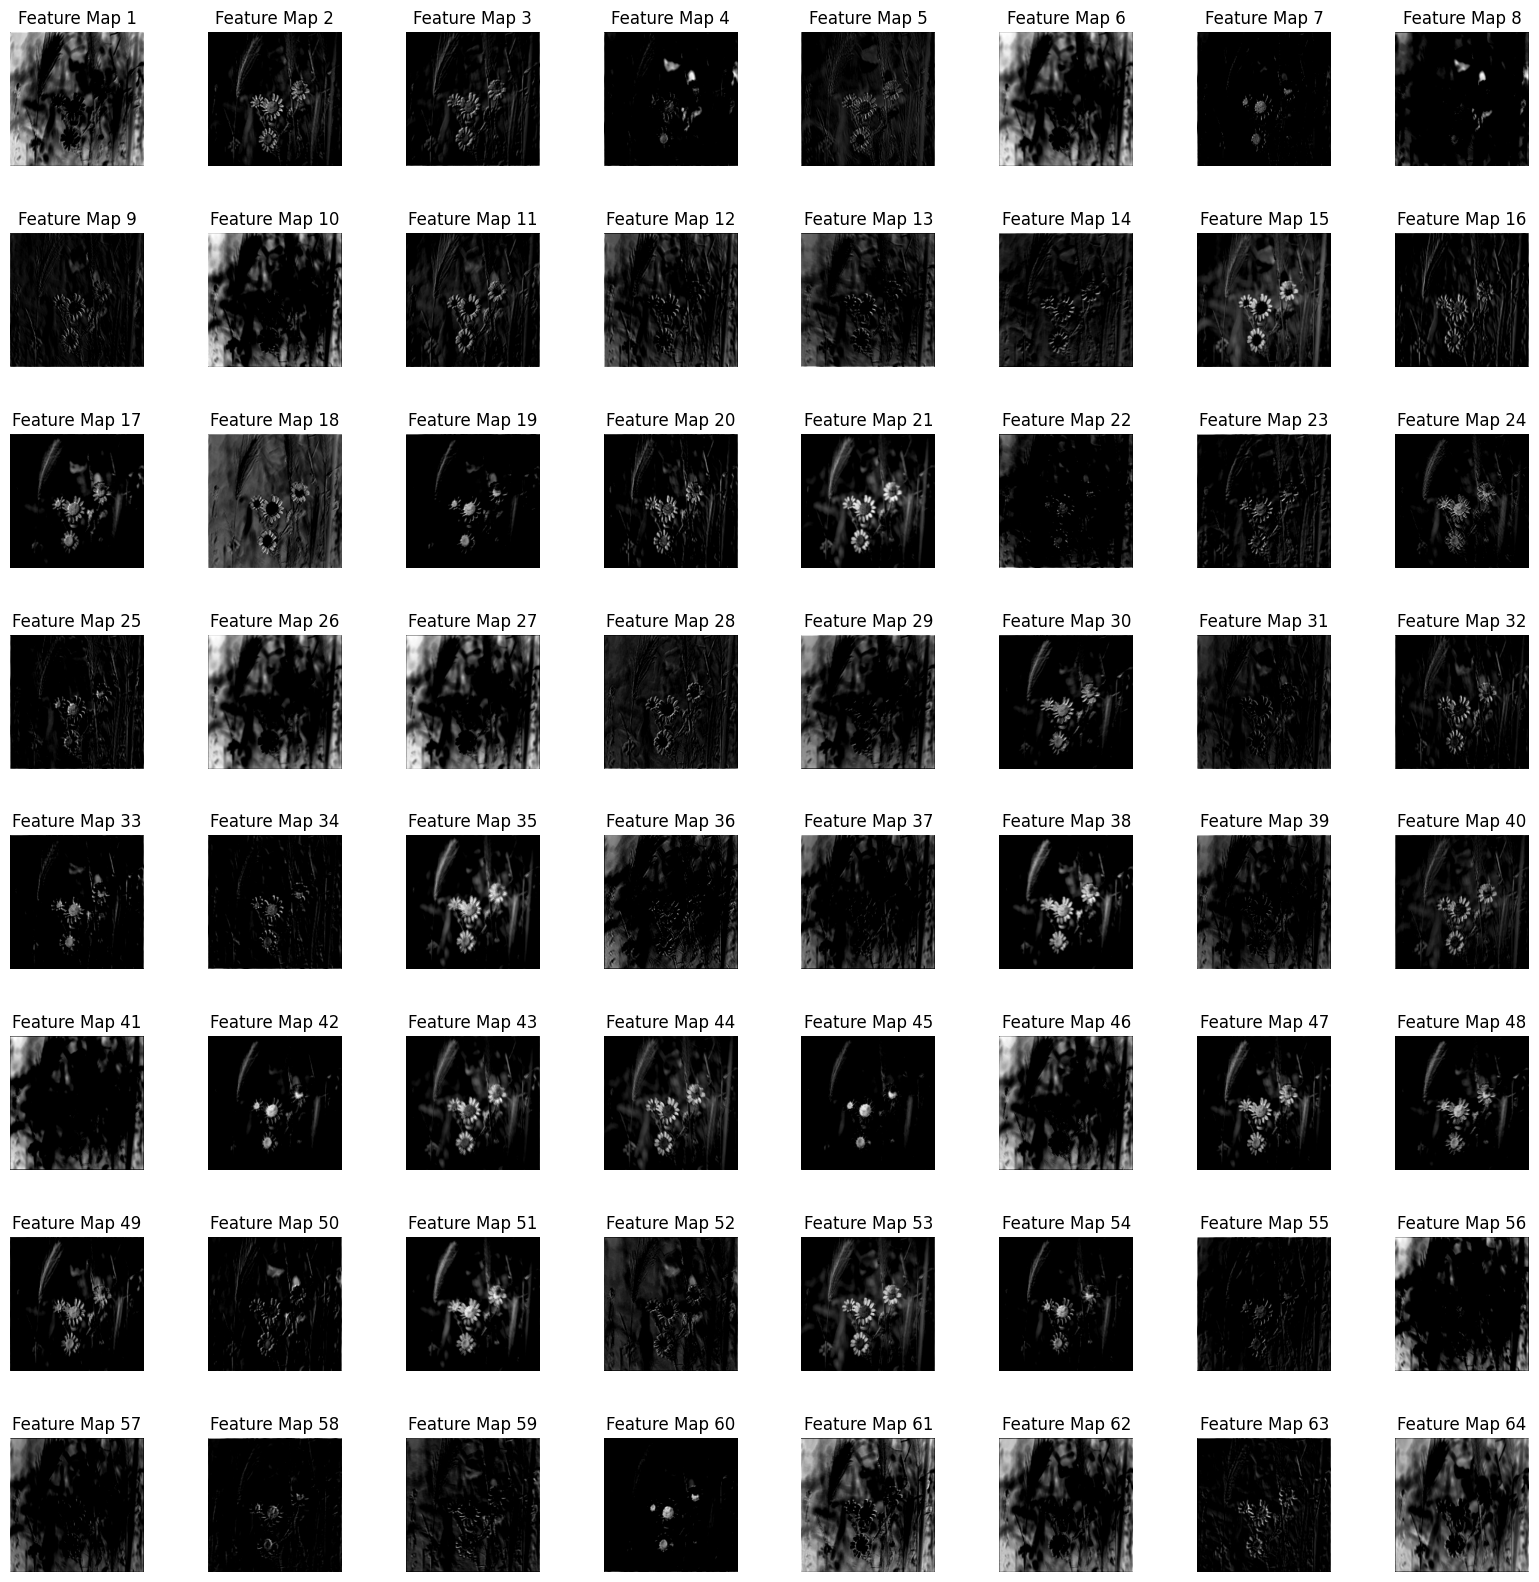

In [ ]:
images, labels = next(iter(testloader))
plot_feature_maps(model, images[10].to(device), 0)

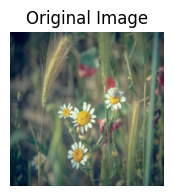

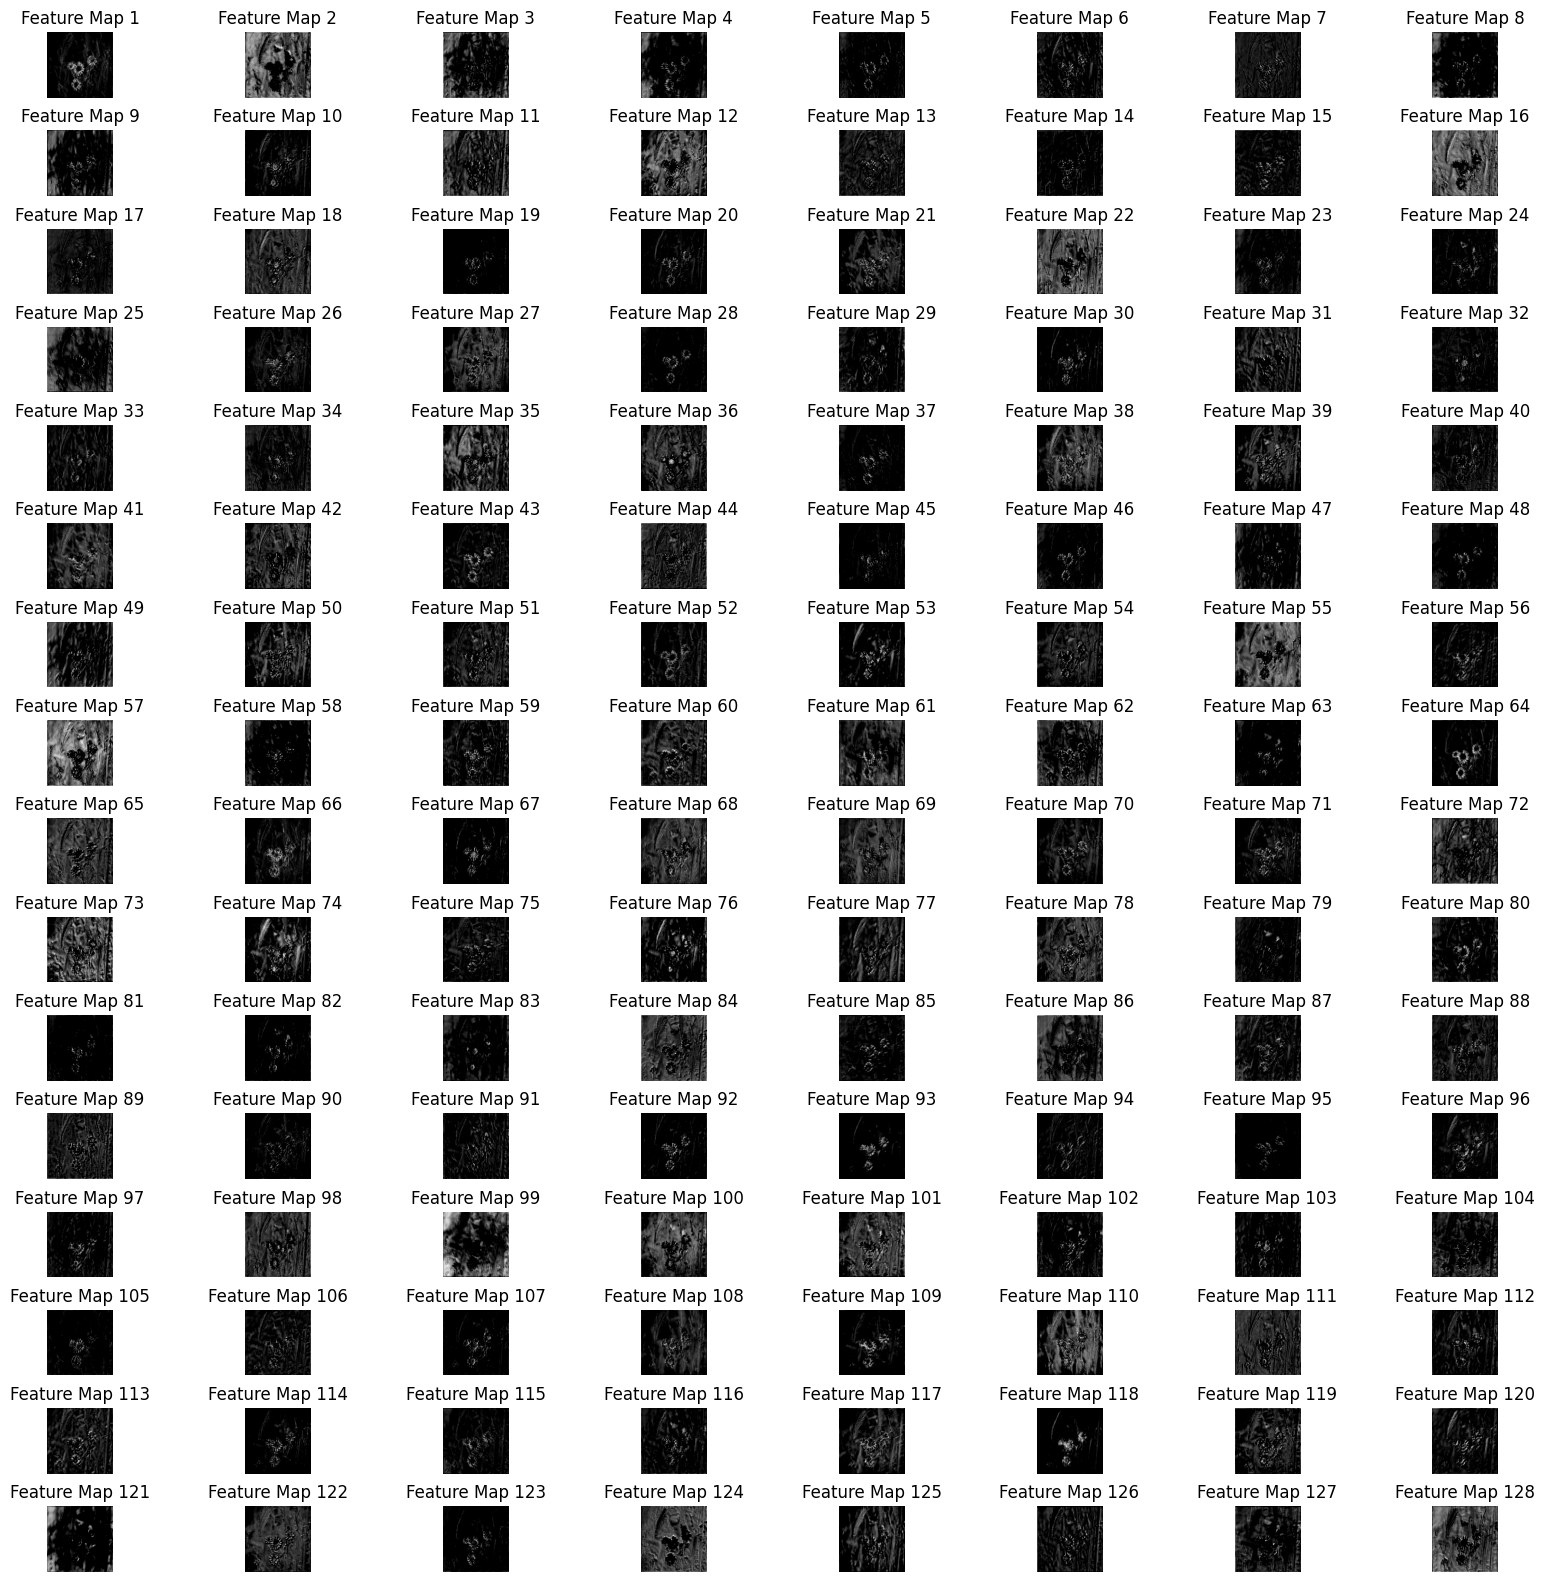

In [ ]:
plot_feature_maps(model, images[10].to(device), 1)

In [ ]:
class vgg16_resnet(nn.Module):
  def __init__(self, num_classes=10):
    super(vgg16_resnet, self).__init__()

    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(64)
    self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)
    self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(128)

    self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn5 = nn.BatchNorm2d(256)
    self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn6 = nn.BatchNorm2d(256)
    self.conv7 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
    self.bn7 = nn.BatchNorm2d(256)

    self.conv8 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
    self.bn8 = nn.BatchNorm2d(512)
    self.conv9 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn9 = nn.BatchNorm2d(512)
    self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn10 = nn.BatchNorm2d(512)

    self.conv11 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn11 = nn.BatchNorm2d(512)
    self.conv12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn12 = nn.BatchNorm2d(512)
    self.conv13 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
    self.bn13 = nn.BatchNorm2d(512)

    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    self.fc1 = nn.Linear(512 * 7 * 7, 4096)
    self.dropuot = nn.Dropout(0.5)
    self.fc2 = nn.Linear(4096, 4096)
    self.fc3 = nn.Linear(4096, num_classes)

  def forward(self, x):
    feature_map1 = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(feature_map1)) + feature_map1)
    x = self.pool(x)

    feature_map2 = F.relu(self.bn3(self.conv3(x)))
    x = F.relu(self.bn4(self.conv4(feature_map2)) + feature_map2)
    x = self.pool(x)

    feature_map3 = F.relu(self.bn5(self.conv5(x)))
    x = F.relu(self.bn6(self.conv6(feature_map3)))
    x = F.relu(self.bn7(self.conv7(x)) + feature_map3)
    x = self.pool(x)

    feature_map4 = F.relu(self.bn8(self.conv8(x)))
    x = F.relu(self.bn9(self.conv9(feature_map4)))
    x = F.relu(self.bn10(self.conv10(x)) + feature_map4)
    x = self.pool(x)

    feature_map5 = F.relu(self.bn11(self.conv11(x)))
    x = F.relu(self.bn12(self.conv12(feature_map5)))
    x = F.relu(self.bn13(self.conv13(x)) + feature_map5)
    x = self.pool(x)

    x = x.view(-1, 512 * 7 * 7)
    x = F.relu(self.fc1(x))
    x = self.dropuot(x)
    x = F.relu(self.fc2(x))
    x = self.dropuot(x)
    x = self.fc3(x)
    return x, feature_map1, feature_map2, feature_map3, feature_map4, feature_map5

input = torch.randn(1, 3, 224, 224)
model = vgg16_resnet()
output = model(input)
for i in range(6):
  print(output[i].shape)


torch.Size([1, 10])
torch.Size([1, 64, 224, 224])
torch.Size([1, 128, 112, 112])
torch.Size([1, 256, 56, 56])
torch.Size([1, 512, 28, 28])
torch.Size([1, 512, 14, 14])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = vgg16_resnet(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
training_losses, trainig_accuracy, validation_losses, validation_accuracy = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=20, device = device)

Validating: 100%|██████████| 7/7 [00:00<00:00, 11.39it/s]



Epoch [1/20], Training Loss: 1.7120, Training Accuracy: 36.63% Validation Loss: 1.2292, Validation Accuracy: 47.80%


Validating: 100%|██████████| 7/7 [00:00<00:00, 11.37it/s]



Epoch [2/20], Training Loss: 1.1141, Training Accuracy: 54.59% Validation Loss: 1.0029, Validation Accuracy: 62.41%


Validating: 100%|██████████| 7/7 [00:00<00:00, 11.37it/s]


...


Epoch [18/20], Training Loss: 0.4385, Training Accuracy: 83.75% Validation Loss: 1.4031, Validation Accuracy: 61.02%


Validating: 100%|██████████| 7/7 [00:00<00:00, 11.39it/s]



Epoch [19/20], Training Loss: 0.3940, Training Accuracy: 86.16% Validation Loss: 0.6914, Validation Accuracy: 76.10%


Validating: 100%|██████████| 7/7 [00:00<00:00, 11.27it/s]


Epoch [20/20], Training Loss: 0.3499, Training Accuracy: 86.42% Validation Loss: 0.5853, Validation Accuracy: 79.12%


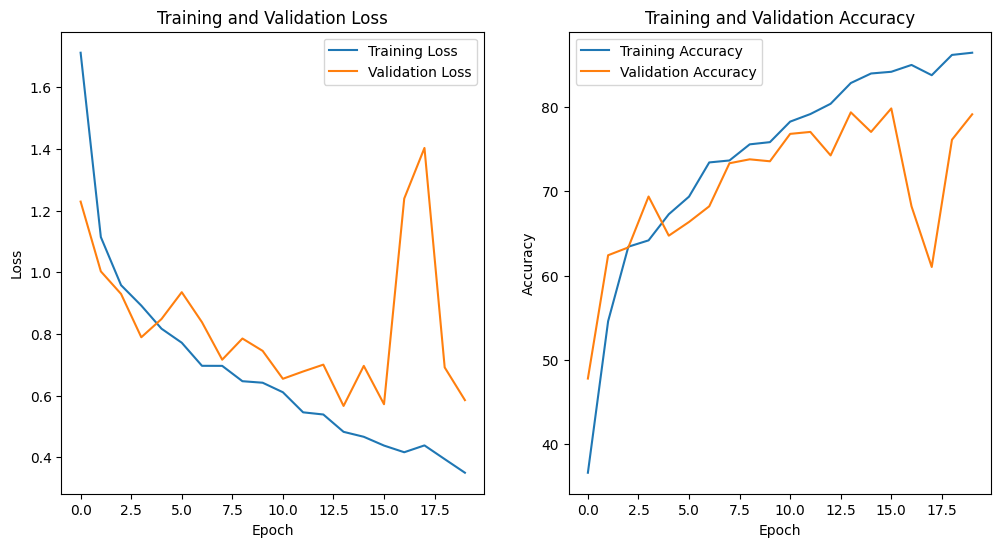

In [ ]:
plot_loss_accuracy(training_losses, trainig_accuracy, validation_losses, validation_accuracy)

In [ ]:
test_model(model, testloader, device)

Accuracy of the model on the test images: 79.91%


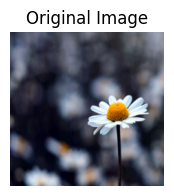

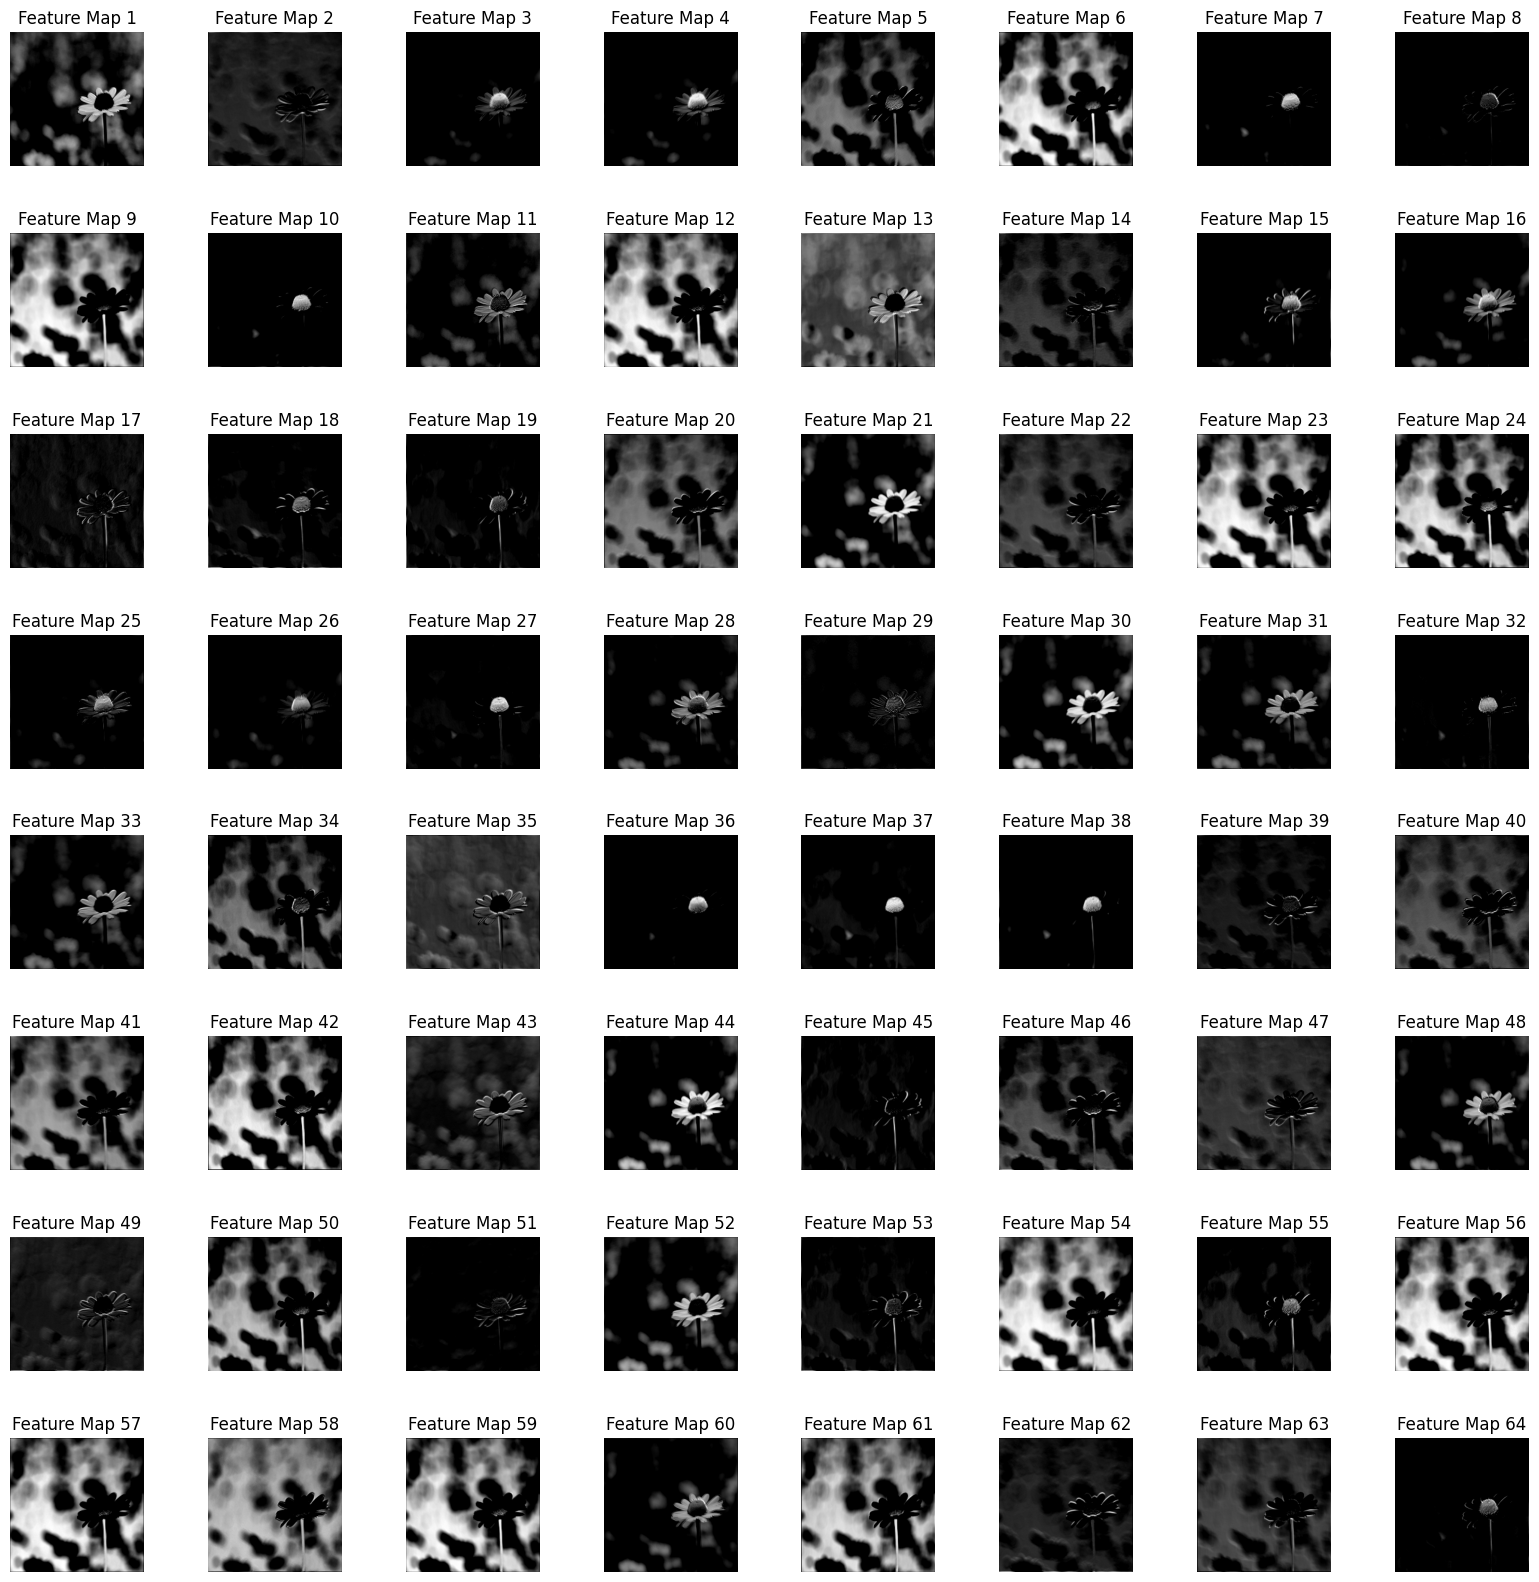

In [ ]:
images, labels = next(iter(testloader))
plot_feature_maps(model, images[0].to(device), 0)

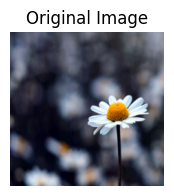

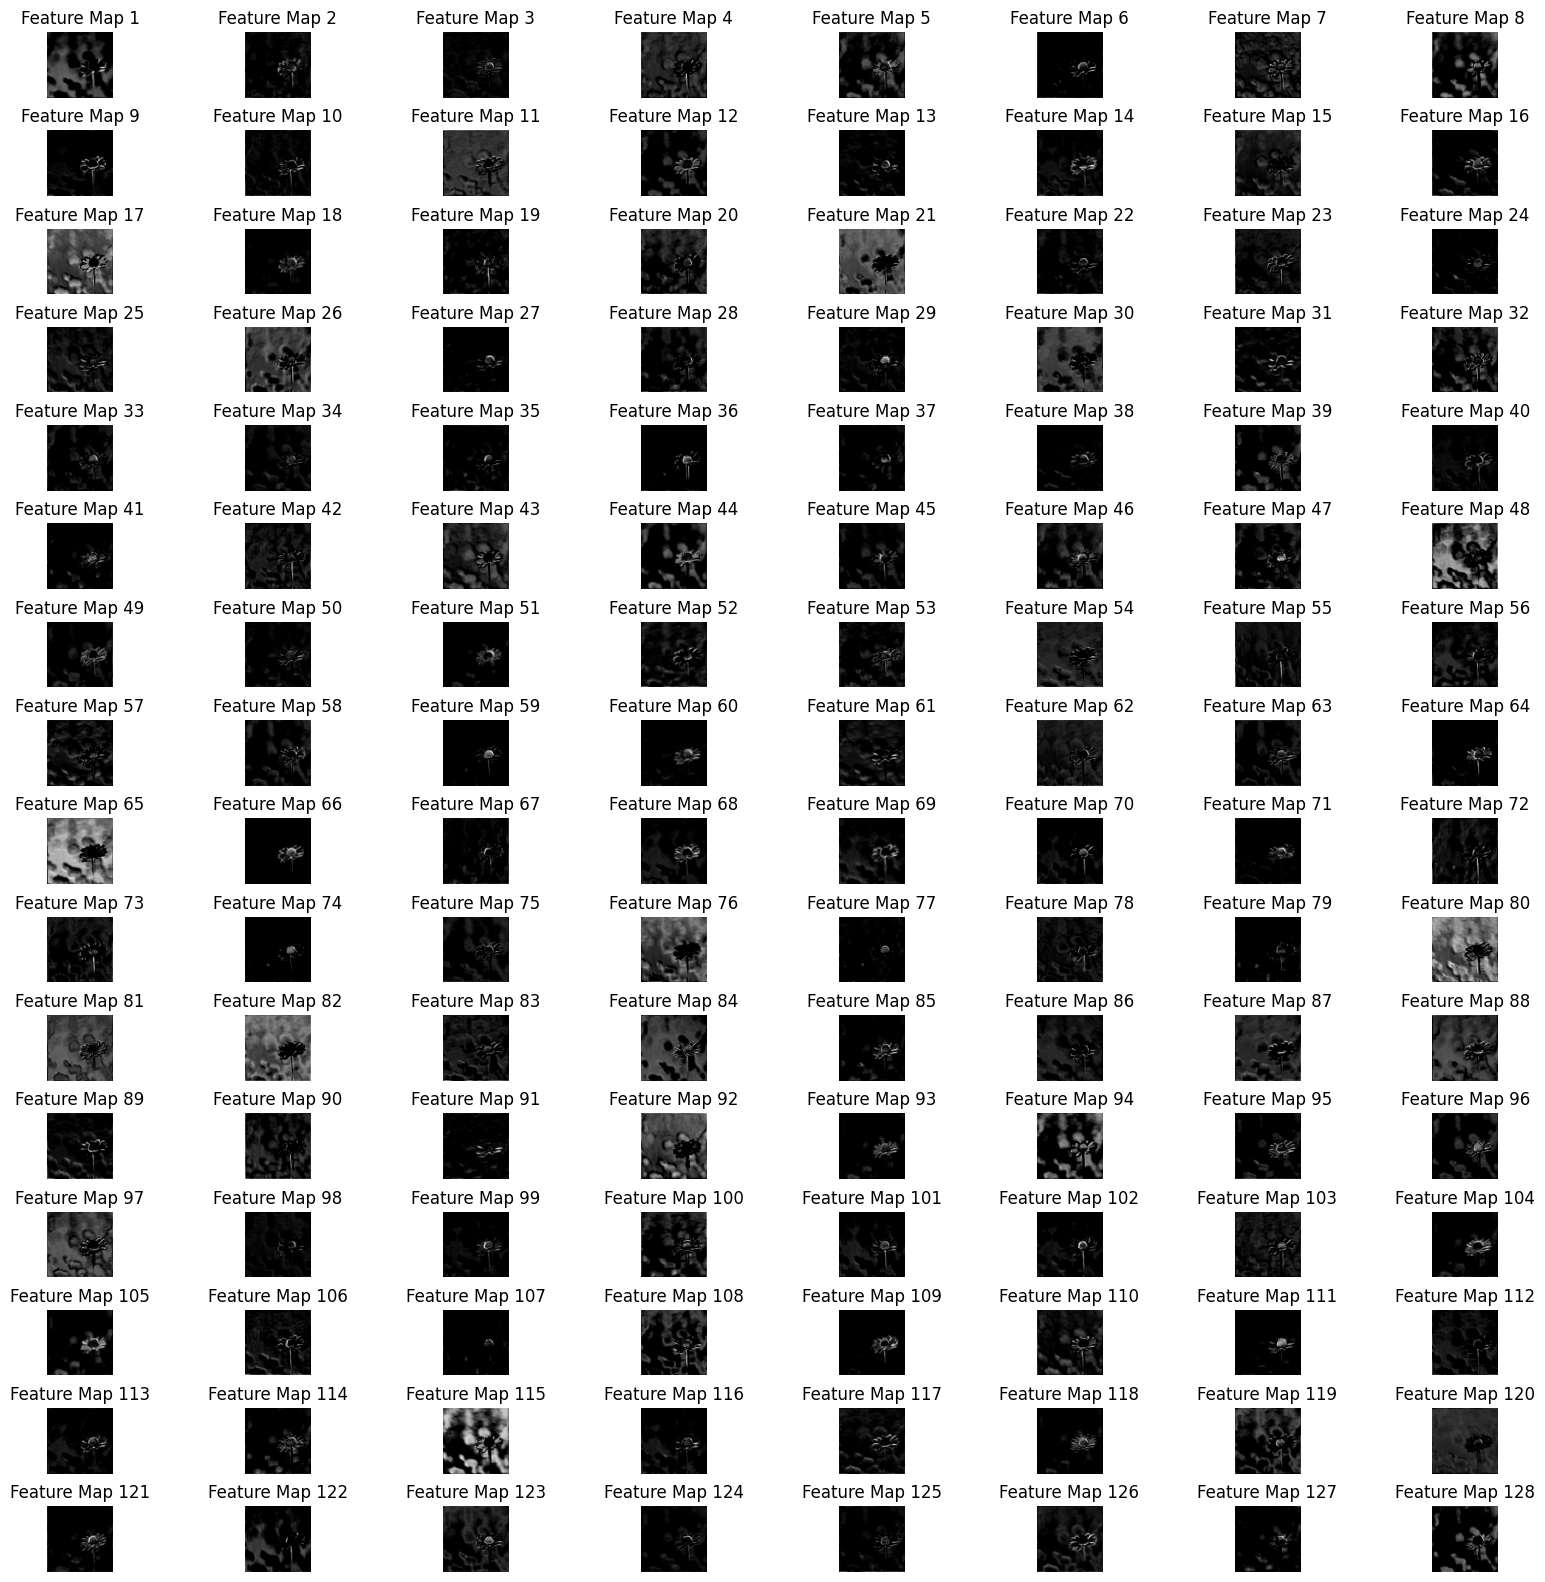

In [ ]:
plot_feature_maps(model, images[0].to(device), 1)

In [ ]:
class InceptionModule(nn.Module):
    def __init__(self, in_channels):
        super(InceptionModule, self).__init__()

        self.conv1x1 = nn.Conv2d(in_channels, 64, kernel_size=1, padding=0)

        self.conv3x3 = nn.Conv2d(in_channels, 128, kernel_size=3, padding=1)

        self.conv5x5 = nn.Conv2d(in_channels, 32, kernel_size=5, padding=2)

        self.pool = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.pool_conv = nn.Conv2d(in_channels, 32, kernel_size=1, padding=0)

        self.relu = nn.ReLU()

    def forward(self, x):
        branch1 = self.relu(self.conv1x1(x))
        branch2 = self.relu(self.conv3x3(x))
        branch3 = self.relu(self.conv5x5(x))
        branch4 = self.relu(self.pool_conv(self.pool(x)))

        return torch.cat([branch1, branch2, branch3, branch4], dim=1)

class VGG16_Inception(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG16_Inception, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        self.inception1 = InceptionModule(128)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

        self.inception2 = InceptionModule(256)
        self.conv6 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        self.conv8 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(512 * 7 * 7, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, num_classes)

    def forward(self, x):
        # First Conv Block
        feature_map1 = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(feature_map1))
        x = self.pool(x)

        # Second Conv Block
        feature_map2 = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(feature_map2))
        x = self.pool(x)

        # Third Block (Inception)
        feature_map3 = self.inception1(x)
        x = torch.relu(self.conv5(feature_map3))
        x = self.pool(x)

        # Fourth Block (Inception)
        feature_map4 = self.inception2(x)
        x = torch.relu(self.conv6(feature_map4))
        x = torch.relu(self.conv7(x))
        x = self.pool(x)

        # Fifth Conv Block
        feature_map5 = torch.relu(self.conv8(x))
        x = torch.relu(self.conv9(feature_map5))
        x = torch.relu(self.conv10(x))
        x = self.pool(x)

        # Fully Connected Layers
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x, feature_map1, feature_map2, feature_map3, feature_map4, feature_map5

input = torch.randn(1, 3, 224, 224)
model = VGG16_Inception()
output = model(input)
for i in range(6):
  print(output[i].shape)

torch.Size([1, 10])
torch.Size([1, 64, 224, 224])
torch.Size([1, 128, 112, 112])
torch.Size([1, 256, 56, 56])
torch.Size([1, 256, 28, 28])
torch.Size([1, 512, 14, 14])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG16_Inception(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
training_losses, trainig_accuracy, validation_losses, validation_accuracy = train_model(model, trainloader, valloader, criterion, optimizer, num_epochs=20, device = device)

Validating: 100%|██████████| 7/7 [00:00<00:00, 13.77it/s]



Epoch [1/20], Training Loss: 1.6024, Training Accuracy: 23.89% Validation Loss: 1.5994, Validation Accuracy: 25.52%


Validating: 100%|██████████| 7/7 [00:00<00:00, 13.89it/s]



Epoch [2/20], Training Loss: 1.6008, Training Accuracy: 24.04% Validation Loss: 1.5966, Validation Accuracy: 21.11%


Validating: 100%|██████████| 7/7 [00:00<00:00, 14.08it/s]


...


Epoch [18/20], Training Loss: 0.4709, Training Accuracy: 83.38% Validation Loss: 1.8251, Validation Accuracy: 59.63%


Validating: 100%|██████████| 7/7 [00:00<00:00, 13.69it/s]



Epoch [19/20], Training Loss: 0.3707, Training Accuracy: 87.49% Validation Loss: 2.0523, Validation Accuracy: 63.34%


Validating: 100%|██████████| 7/7 [00:00<00:00, 13.69it/s]


Epoch [20/20], Training Loss: 0.3226, Training Accuracy: 89.23% Validation Loss: 2.0355, Validation Accuracy: 61.25%


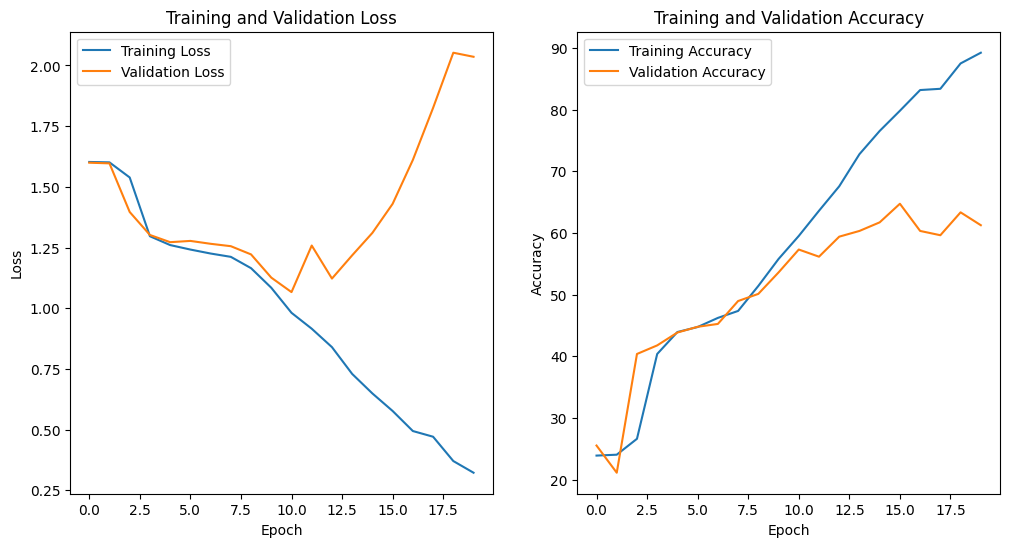

In [ ]:
plot_loss_accuracy(training_losses, trainig_accuracy, validation_losses, validation_accuracy)

In [ ]:
test_model(model, testloader, device)

Accuracy of the model on the test images: 55.43%


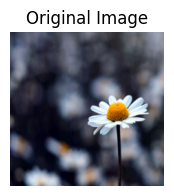

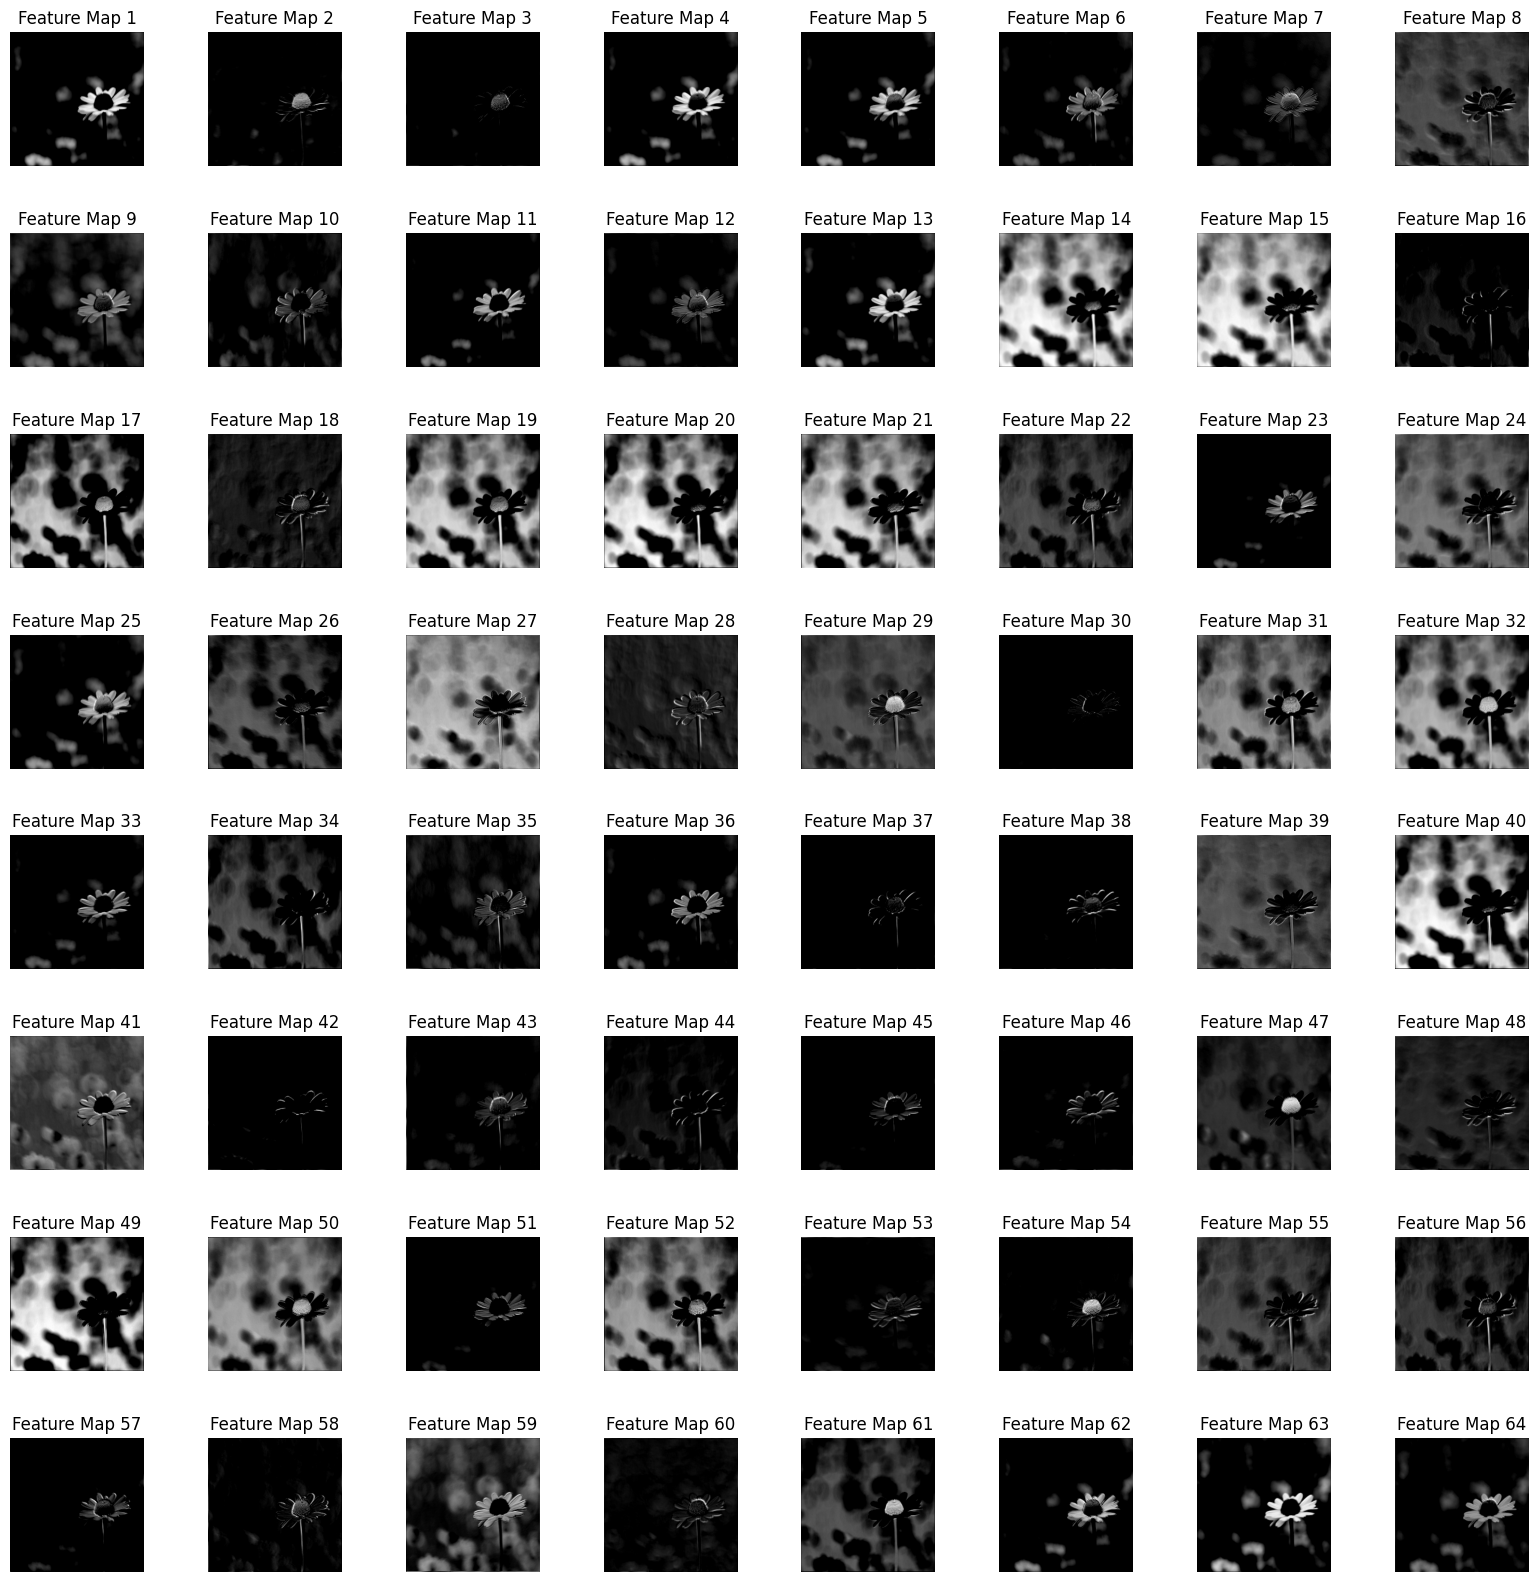

In [ ]:
images, labels = next(iter(testloader))
plot_feature_maps(model, images[0].to(device), 0)

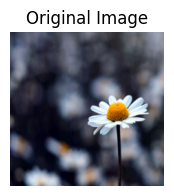

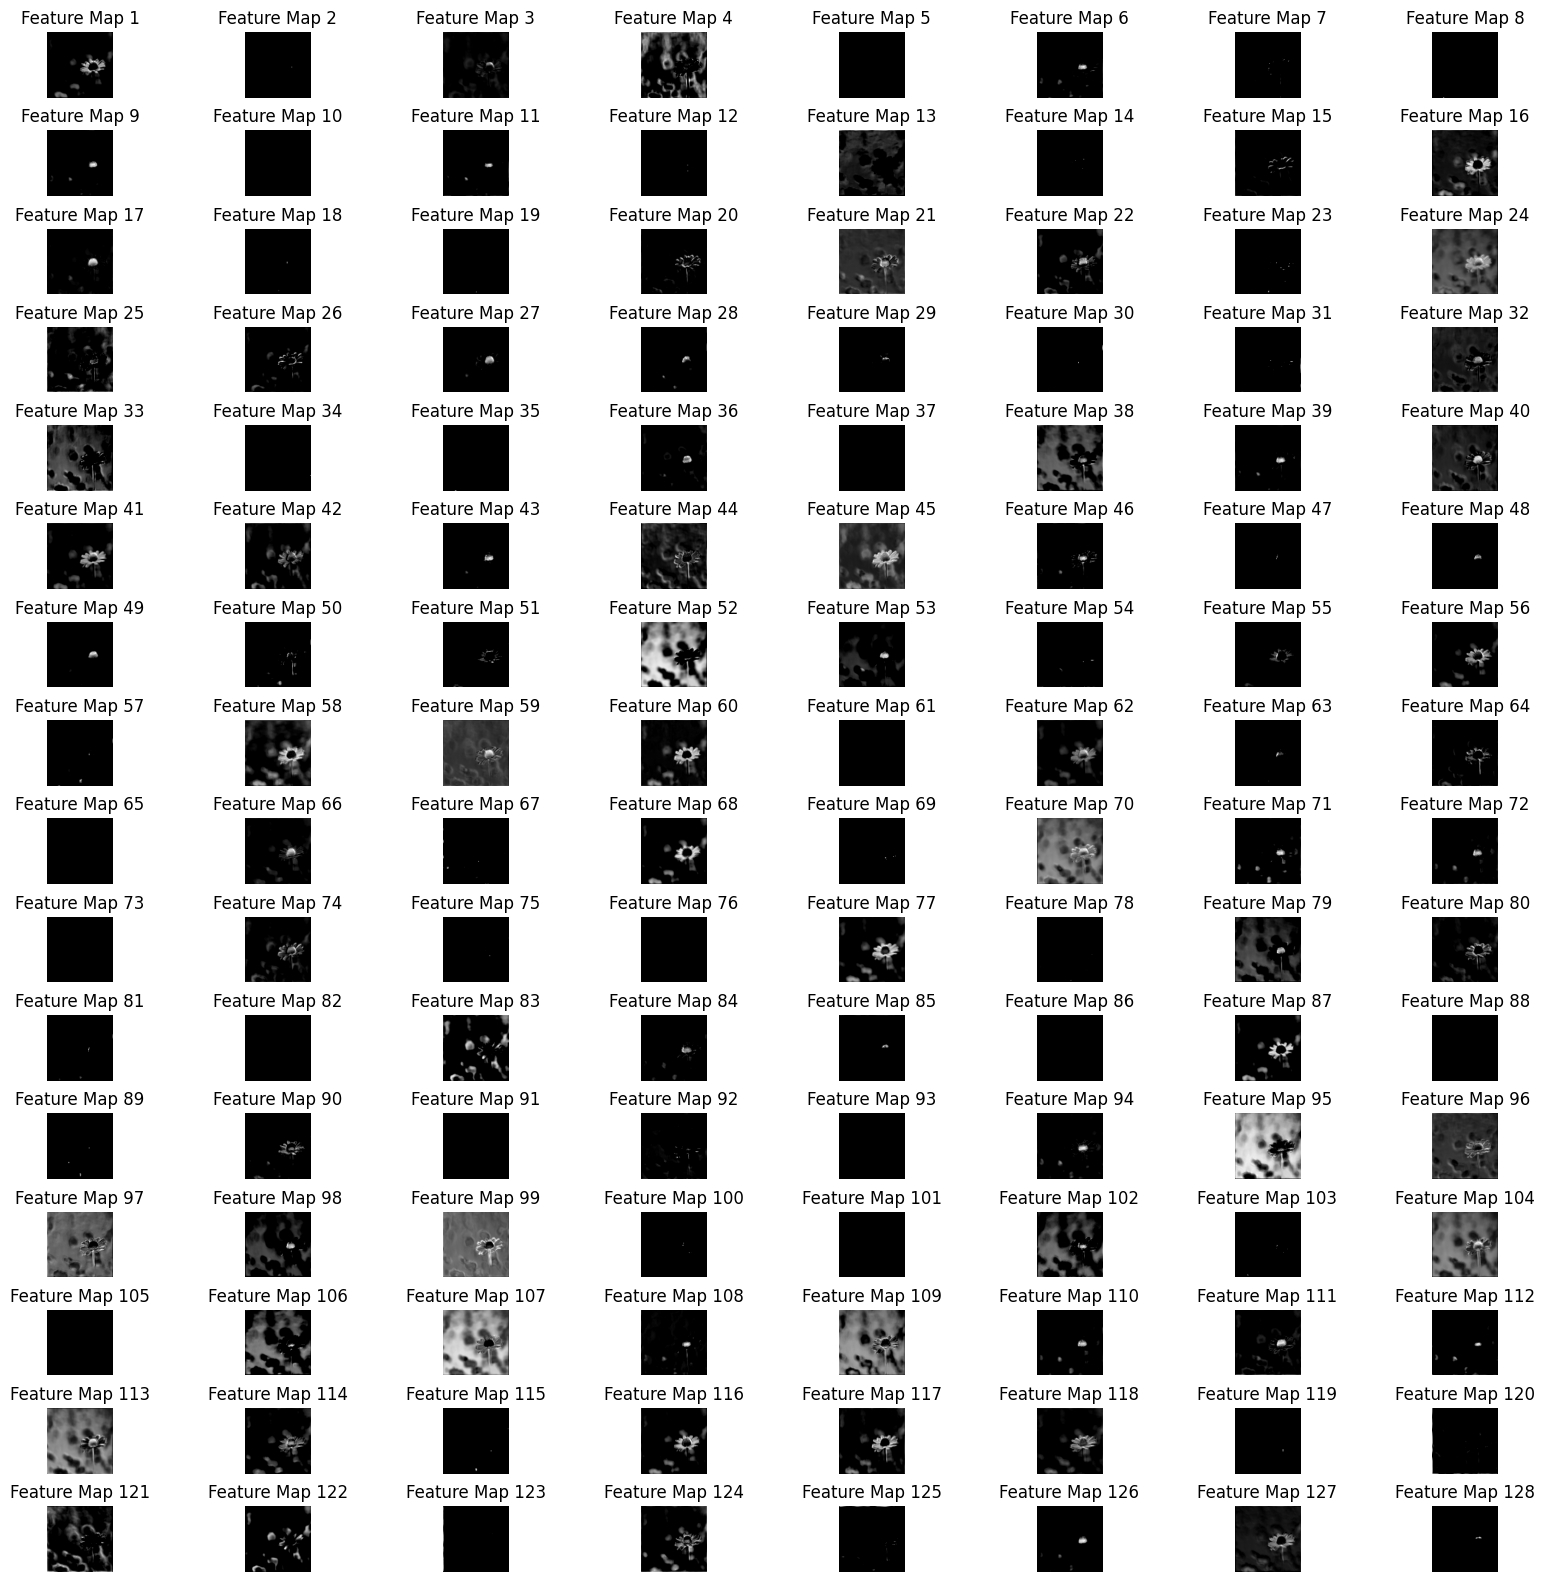

In [ ]:
plot_feature_maps(model, images[0].to(device), 1)

In [ ]:
def reset_weights(model):
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()

In [ ]:
import torch.optim as optim

def train_all_models(models_dict, train_loader, val_loader, optimizers, learning_rates, criterion, num_epochs=10, device='cpu'):

    results = []

    for model_name, model in models_dict.items():
        for opt_name in optimizers:
            for lr in learning_rates:
                print(f"\nTraining {model_name} with {opt_name.upper()} and LR={lr}")

                reset_weights(model)

                # Initialize optimizer
                if opt_name.lower() == "adam":
                    optimizer = optim.Adam(model.parameters(), lr=lr)
                elif opt_name.lower() == "sgd":
                    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
                elif opt_name.lower() == "rmsprop":
                    optimizer = optim.RMSprop(model.parameters(), lr=lr)
                else:
                    raise ValueError(f"Invalid optimizer: {opt_name}")

                # Move model to device
                model.to(device)

                # Train the model using your existing function
                train_losses, train_acc, val_losses, val_acc = train_model(
                    model, train_loader, val_loader, criterion, optimizer, num_epochs, device
                )

                # Store results
                results.append((model_name, opt_name, lr, train_losses, train_acc, val_losses, val_acc))

    return results


In [ ]:
models_dict = {
    "VGG16": vgg16(num_classes=5),
    "VGG16_Inception": VGG16_Inception(num_classes=5),
    "VGG16_ResNet": vgg16_resnet(num_classes=5)
}

# Define hyperparameters
optimizers = ["adam", "sgd", "rmsprop"]
learning_rates = [0.001, 0.01, 0.1]

criterion = nn.CrossEntropyLoss()

# Train all models
results = train_all_models(models_dict, trainloader, valloader, optimizers, learning_rates, criterion, num_epochs=10, device="cuda")


Training VGG16 with ADAM and LR=0.001


Validating: 100%|██████████| 7/7 [00:00<00:00, 10.88it/s]



Epoch [1/10], Training Loss: 5.4977, Training Accuracy: 23.66% Validation Loss: 1.5903, Validation Accuracy: 32.95%


Validating: 100%|██████████| 7/7 [00:00<00:00, 11.08it/s]



Epoch [2/10], Training Loss: 1.5068, Training Accuracy: 32.93% Validation Loss: 1.4657, Validation Accuracy: 37.35%


...


Epoch [8/10], Training Loss: 107722.9726, Training Accuracy: 24.04% Validation Loss: 26854.7067, Validation Accuracy: 24.36%


Validating: 100%|██████████| 7/7 [00:00<00:00, 10.66it/s]



Epoch [9/10], Training Loss: 59773.4996, Training Accuracy: 24.56% Validation Loss: 9951.5147, Validation Accuracy: 26.91%


Validating: 100%|██████████| 7/7 [00:00<00:00, 10.64it/s]


Epoch [10/10], Training Loss: 29649.1726, Training Accuracy: 25.43% Validation Loss: 8171.3055, Validation Accuracy: 25.06%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_results(results):
    """
    Plots training & validation loss and accuracy for multiple models trained with different optimizers & learning rates.
    Handles NaN values by skipping them in plots.

    Parameters:
        results (list): List of (model_name, optimizer, lr, training_losses, training_acc, val_losses, val_acc).
    """

    fig, axes = plt.subplots(2, 2, figsize=(25, 15))  # Create subplots (2 rows, 2 cols)
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']  # Different colors for plots
    line_styles = ['-', '--', '-.', ':']  # Different line styles

    for i, (model_name, optimizer, lr, train_losses, train_acc, val_losses, val_acc) in enumerate(results):
        label = f"{model_name} ({optimizer.upper()}, LR={lr})"
        color = colors[i % len(colors)]  # Cycle through colors
        style = line_styles[i % len(line_styles)]  # Cycle through line styles

        # Convert lists to NumPy arrays for easier NaN handling
        train_losses = np.array(train_losses, dtype=np.float32)
        train_acc = np.array(train_acc, dtype=np.float32)
        val_losses = np.array(val_losses, dtype=np.float32)
        val_acc = np.array(val_acc, dtype=np.float32)

        # Mask NaN values (only plot valid points)
        def valid_values(arr):
            return np.where(~np.isnan(arr), arr, np.nan)

        # Check if all values are NaN in any plot (avoid blank graphs)
        if np.isnan(train_losses).all():
            print(f"Warning: Training loss has all NaN values for {label}")
            continue
        if np.isnan(train_acc).all():
            print(f"Warning: Training accuracy has all NaN values for {label}")
            continue
        if np.isnan(val_losses).all():
            print(f"Warning: Validation loss has all NaN values for {label}")
            continue
        if np.isnan(val_acc).all():
            print(f"Warning: Validation accuracy has all NaN values for {label}")
            continue

        # Training Loss
        axes[0, 0].plot(valid_values(train_losses), color=color, linestyle=style, label=label)
        axes[0, 0].set_title("Training Loss")
        axes[0, 0].set_xlabel("Epochs")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].legend()

        # Training Accuracy
        axes[0, 1].plot(valid_values(train_acc), color=color, linestyle=style, label=label)
        axes[0, 1].set_title("Training Accuracy")
        axes[0, 1].set_xlabel("Epochs")
        axes[0, 1].set_ylabel("Accuracy (%)")
        axes[0, 1].legend()

        # Validation Loss
        axes[1, 0].plot(valid_values(val_losses), color=color, linestyle=style, label=label)
        axes[1, 0].set_title("Validation Loss")
        axes[1, 0].set_xlabel("Epochs")
        axes[1, 0].set_ylabel("Loss")
        axes[1, 0].legend()

        # Validation Accuracy
        axes[1, 1].plot(valid_values(val_acc), color=color, linestyle=style, label=label)
        axes[1, 1].set_title("Validation Accuracy")
        axes[1, 1].set_xlabel("Epochs")
        axes[1, 1].set_ylabel("Accuracy (%)")
        axes[1, 1].legend()

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()


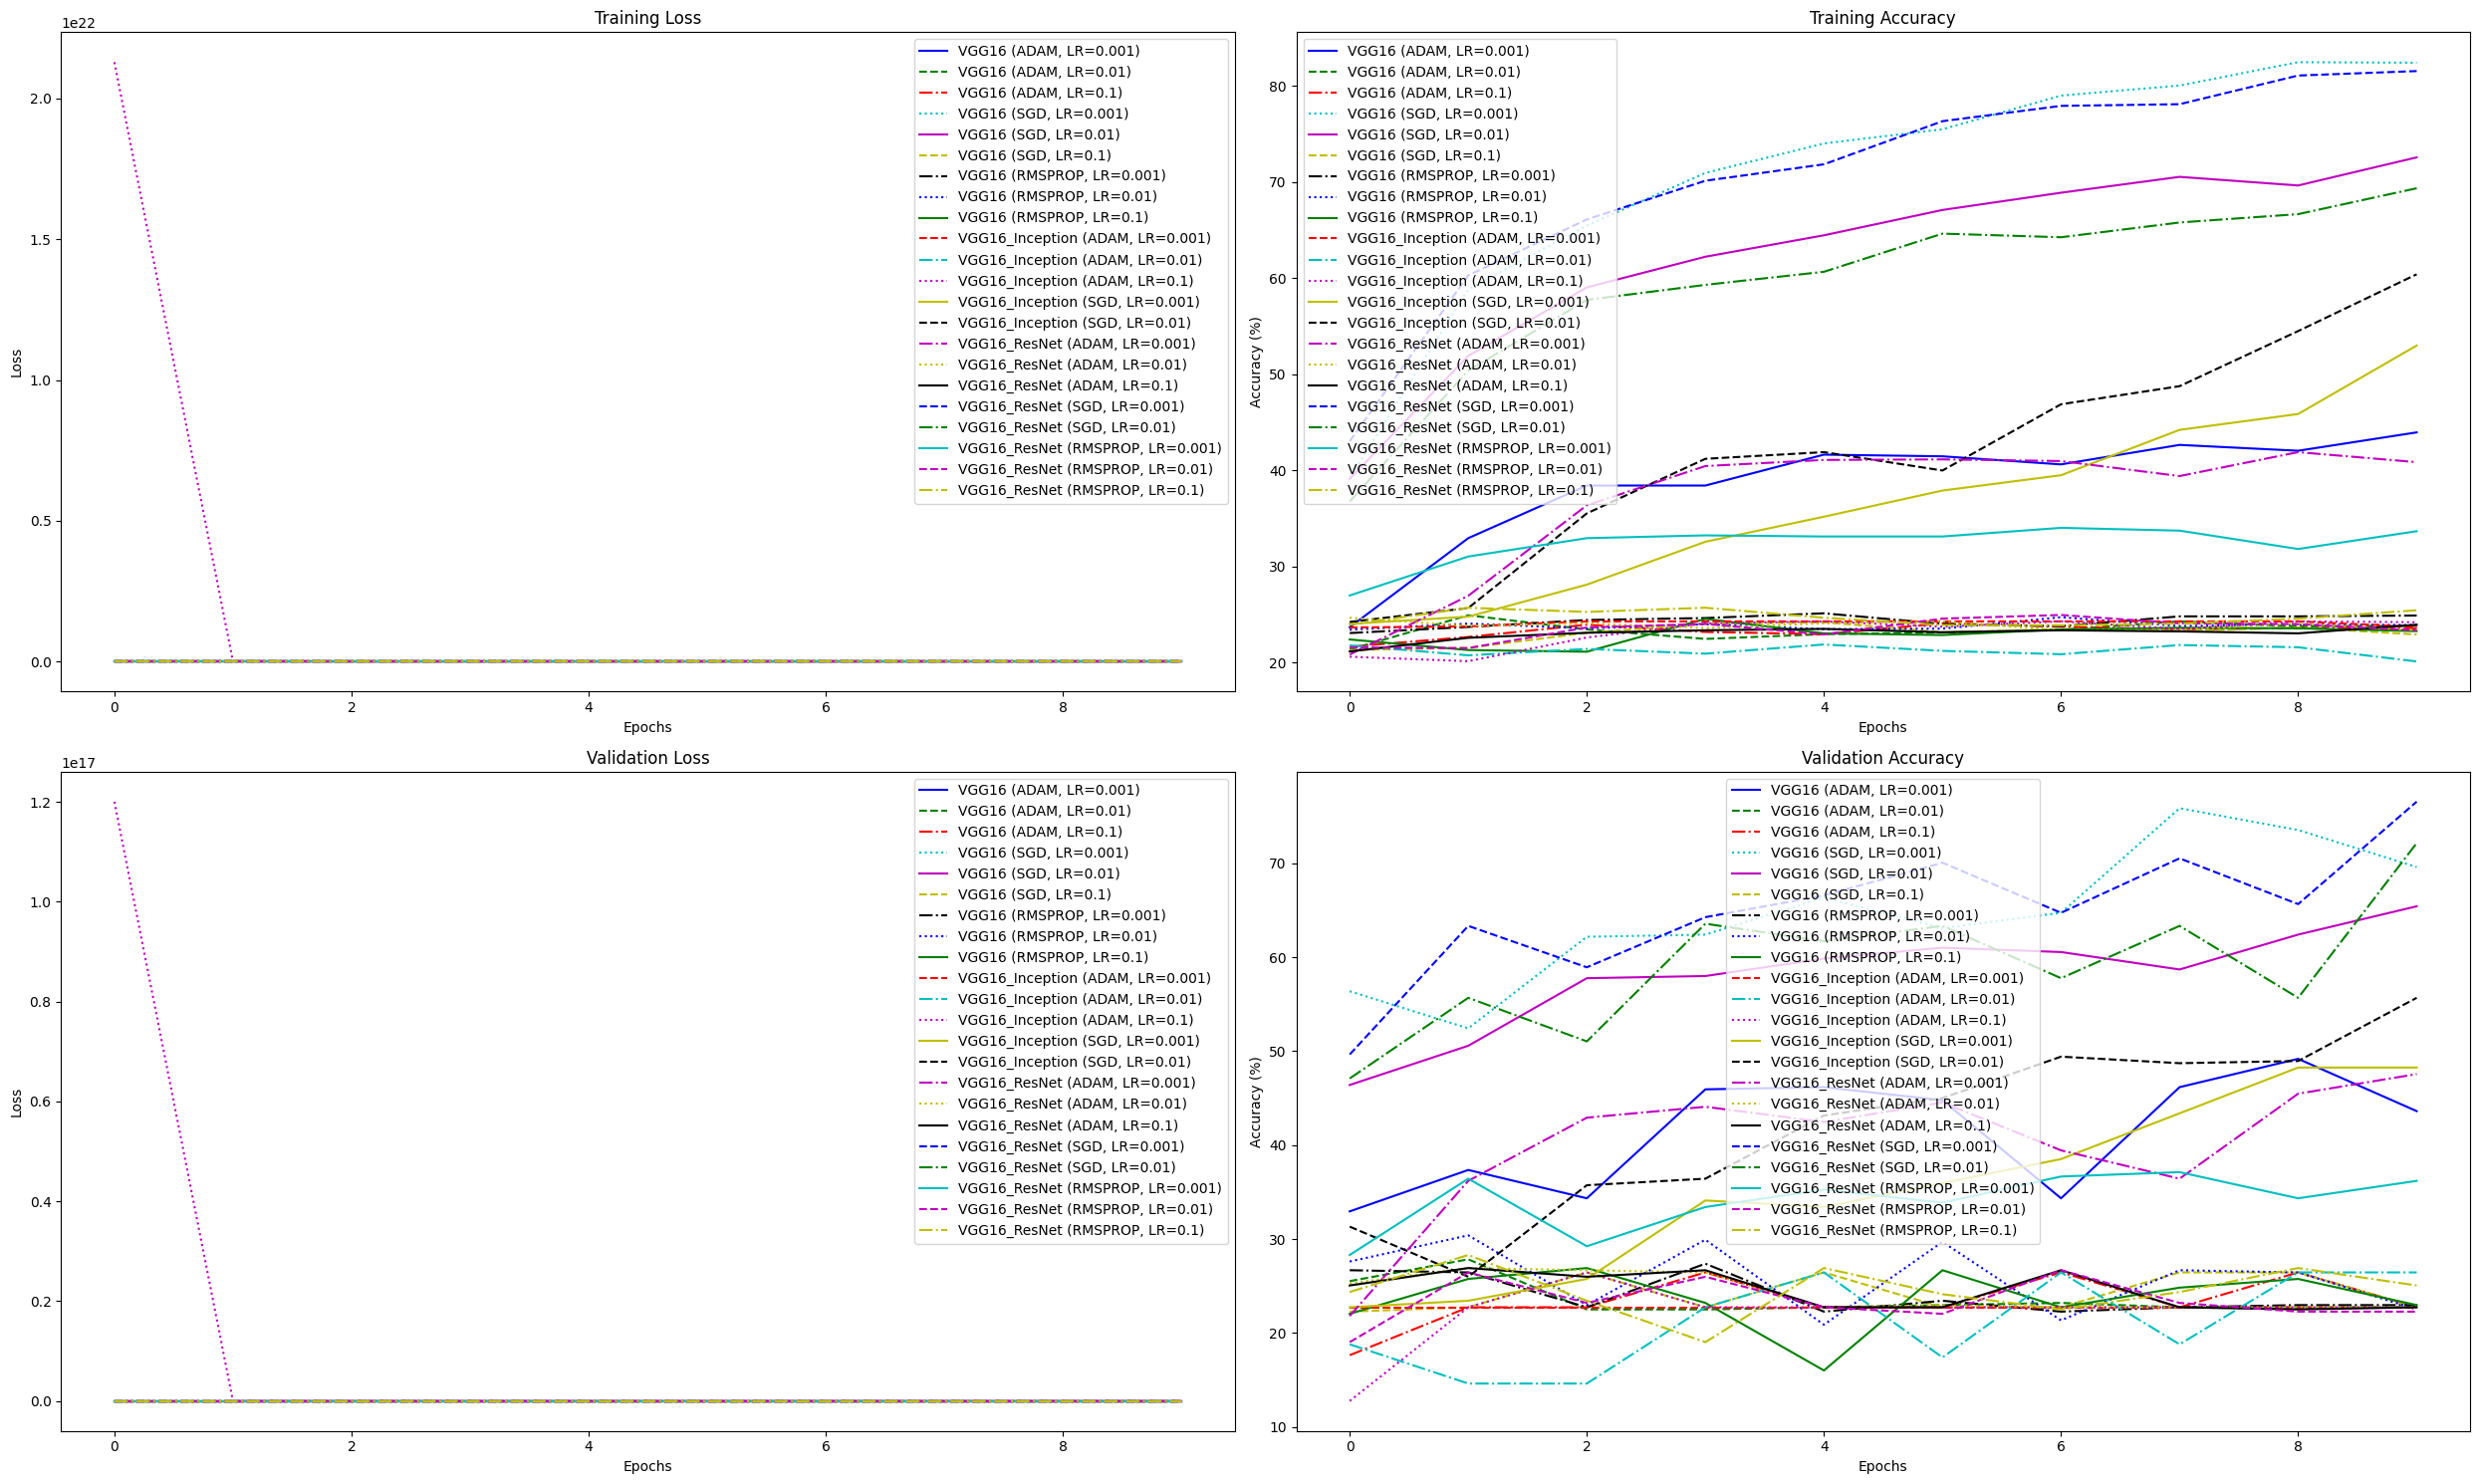

In [ ]:
plot_all_results(results)